# House Price Prediction

## Problem
ntw93o prix des maisons based 3la house sizes

## Goal
Nbniw model y9der yt3amel tres bien m3a hd l problem et surtt les données li 3omrah ma chafha

### Imports

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

### Data Exploration

In [110]:
np.random.seed(42)
X = np.linspace(40, 100, 50).reshape(-1, 1)
y = 2 * X.flatten() + np.random.normal(0, 10, size=50)

### Visualization

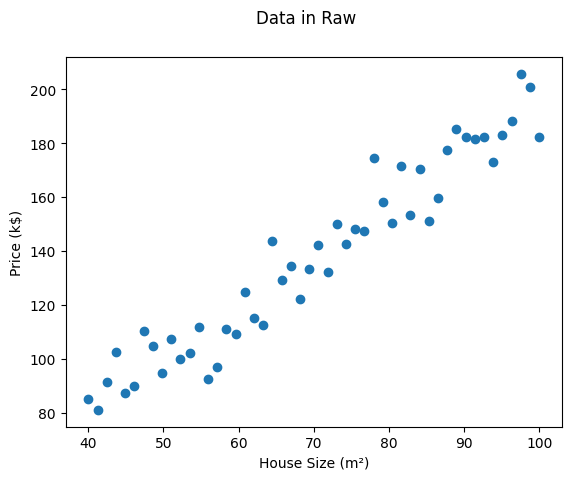

In [111]:
plt.scatter(X, y)
plt.xlabel("House Size (m²)")
plt.ylabel("Price (k$)")
plt.suptitle("Data in Raw")
plt.show()

### Data Splitting

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

test data hiya a9das 7aja f projet lol🤣🤣

### Feature Engineering
hnaya gha n9der nzid features jdad li 9der y3awnou model y9der y3rf prix des maisons comme: 
- number of bedrooms
- number of bathrooms
- location
- etc...

In [113]:
deg = 10
poly = PolynomialFeatures(degree= deg)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

- khdemna b degree bch nkhalliw modele ychof la relation entre les variables comme une courbe complexe mchi khatt mousta9im  simple
- fit: hiya t9der t3llm model 3la les données li 3ndna bach y9der y3rf prix des maisons
- transform (dyal fit): khadma dyalha hiya t9der tzid features jdad li 9der y3awnou model y9der udir prediction mzyana
- fit nst3mlouh uniquement 3la les données d'entrainement bach y3llm model 3la les relations entre les features et le target
- transform uniquement pour le test data wla prediction

- -- Haram: fit_transform(X_test)  →  l-modèle ychouf l-test! --
- -- transform(X_test)  →  ychouf cha 3allmna f train --

| Ligne                     | Ma3na                                   |
| ------------------------- | --------------------------------------- |
| `deg = 10`                | Bghit courbe me3qqed de degree 10      |
| `PolynomialFeatures(...)` | Jib machine dyal transformation       |
| `fit_transform(X_train)`  | 3allm 3la train ou 7awelha              |
| `transform(X_test)`       | 7awel test b nafs ch-chi, bla ma t3allm |


### Selection of Alpha (Cross Validation)

In [114]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_errors = []

for alpha in alphas:
    fold_errors = []
    for train_idx, val_idx in kf.split(X_train_poly):
        X_tr, X_val = X_train_poly[train_idx], X_train_poly[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = Ridge(alpha= alpha)
        model.fit(X_tr, y_tr)

        y_val_pred = model.predict(X_val)
        fold_errors.append(mean_squared_error(y_val, y_val_pred))

    cv_errors.append(np.mean(fold_errors))

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.51058e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.09351e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.9293e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.12435e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.0933e-43): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3

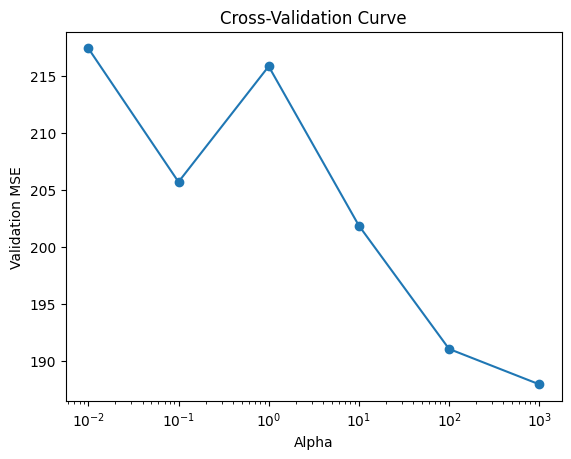

In [115]:
plt.plot(alphas, cv_errors, marker='o')
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Validation MSE")
plt.title("Cross-Validation Curve")
plt.show()

### Train Final Model

In [116]:
best_alpha = alphas[np.argmin(cv_errors)]
print("The Best alpha is: ", best_alpha)

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_poly, y_train)

The Best alpha is:  1000


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.08296e-38): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ridge(alpha=1000)

### Final Evaluation (Examen Dyal BSSH)

In [117]:
y_test_pred = final_model.predict(X_test_poly)
test_mse = mean_squared_error(y_test, y_test_pred)

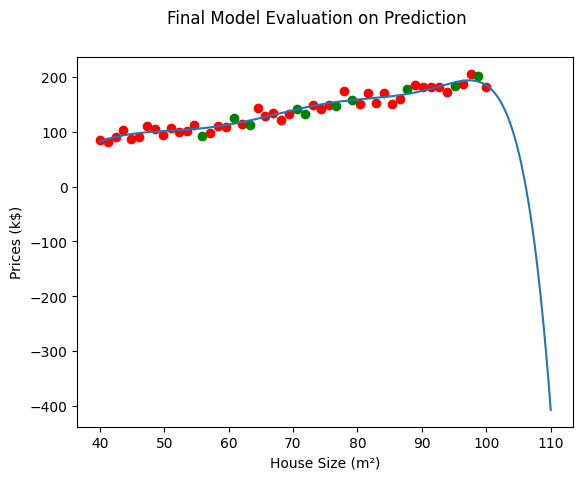

In [118]:
X_line = np.linspace(40, 110, 200).reshape(-1, 1)
X_line_poly = poly.transform(X_line)
y_line = final_model.predict(X_line_poly)

plt.scatter(X_train, y_train, color="red")
plt.scatter(X_test, y_test, color="green")
plt.plot(X_line, y_line)

plt.xlabel("House Size (m²)")
plt.ylabel("Prices (k$)")
plt.suptitle("Final Model Evaluation on Prediction")
plt.show()

### Make Prediction jdida

In [119]:
new_house = np.array([[120]])
new_house_poly = poly.transform(new_house)

prediction = final_model.predict(new_house_poly)
print("Predicted price for 120m²: ", prediction[0])

Predicted price for 120m²:  -4682.473707148378


## Cha sra?

`Predicted price for 120m²:  -4682.473707148378`

hadi nsmiwha data extrapolation, 7it 120m² ma kaynach f train data, w model 9der ydir prediction mzyana 7it 3llm 3la les relations entre les features et le target, w hna kayn extrapolation 7it kayn f outside range dyal train data